In [30]:
# Multiple Hypothesis Testing Correction + VIF + clustered regressions
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from patsy.builtins import Q

out_folder = "/edata/obdw/sandwich_analysis_data/"

# Load stratified data
X_stratified = pd.read_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv", index_col=0)

print("=" * 80)
print("MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. VIF ANALYSIS - keep numeric-only VIF diagnostics
# ============================================================================
print("\n1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("-" * 80)

numeric_cols = [col for col in X_stratified.select_dtypes(include=[np.number]).columns if col != "pid"]
X_for_vif = X_stratified[numeric_cols].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]

def interpret_vif(vif):
    if vif < 5:
        return "OK"
    return "Concerning" if vif < 10 else "SERIOUS"

vif_data["Assessment"] = vif_data["VIF"].apply(interpret_vif)
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string())
vif_data.to_csv(out_folder + "vif_stratified_analysis.csv", index=False)
print(f"\nVIF results saved to: {out_folder}vif_stratified_analysis.csv")

high_vif_features = vif_data.loc[vif_data["VIF"] >= 10, "Variable"].tolist()
print("high_vif_features:", high_vif_features)

if not high_vif_features:
    raise RuntimeError("No VIF >=10 variables")

common = [f for f in high_vif_features if f in X_stratified.columns]
print("common high-VIF cols in X_stratified:", common)

if not common:
    raise RuntimeError("No overlap between VIF variables and X_stratified columns")

numeric_df = X_stratified[common].select_dtypes(include="number")
corr_high_vif = numeric_df.corr()
print("\nCorrelation matrix for high-VIF numeric features:")
print(corr_high_vif)

# ============================================================================
# 2. Primary full-adjusted regression for both outcomes with clustered SE by pid
# ============================================================================
print("\n\n2. PRIMARY FULL-ADJUSTED MODELS (PRESPECIFIED CONFOUNDERS + CLUSTERED SE)")
print("-" * 80)

# Prefer explicitly log-transformed WER if available.
wer_col = next((c for c in ["log_wer", "Y_WER", "WER", "wer"] if c in X_stratified.columns), None)
coh_col = next((c for c in ["Y_COH", "sentCoherenceSentBertCumulativeCentroid"] if c in X_stratified.columns), None)
outcomes = [col for col in [wer_col, coh_col] if col is not None]

if wer_col != "log_wer":
    print(f"WARNING: log_wer not found. Using '{wer_col}' as WER outcome.")

OUTCOME_ALIASES = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}

def select_prespecified_confounders(columns):
    exact_terms = {
        "AMOS",
        "pause_proportion",
        "phq9-total",
        "scl-avg-global-score",
        "hpsvq-voice-score",
        "hpsvq-distress-score",
        "SDS_Total",
        "all_types_drug_use",
        "healthcare_access_score",
        "resource_access_score",
    }
    prefixes = (
        "race_",
        "gender_",
        "binned_age_",
        "dx_group_",
        "education_binned_",
        "employment-status_",
        "sexuality_",
        "svi_theme",
        "PrimaryRUCA_",
    )

    selected = []
    for c in columns:
        if c in OUTCOME_ALIASES or c == "pid":
            continue
        if c in exact_terms or any(c.startswith(p) for p in prefixes):
            selected.append(c)
    return selected

prespecified_terms = select_prespecified_confounders(X_stratified.columns)
if len(prespecified_terms) == 0:
    raise RuntimeError("No prespecified confounders found in dataset columns.")

print(f"Prespecified confounders found: {len(prespecified_terms)}")
print(prespecified_terms)

results_list = []
for outcome_name in outcomes:
    terms = [f'Q("{c}")' for c in prespecified_terms]
    formula = f'Q("{outcome_name}") ~ ' + ' + '.join(terms)

    print(f"\n\nOUTCOME: {outcome_name}")
    print("=" * 80)
    print("Primary full-adjusted formula:")
    print(formula[:400] + ("..." if len(formula) > 400 else ""))

    model = smf.ols(formula=formula, data=X_stratified).fit(
        cov_type="cluster",
        cov_kwds={"groups": X_stratified["pid"], "use_correction": True}
    )

    coef_table = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Std_Error": model.bse.values,
        "t_statistic": model.tvalues.values,
        "p_value": model.pvalues.values
    })

    coef_table["CI_lower"] = coef_table["Coefficient"] - 1.96 * coef_table["Std_Error"]
    coef_table["CI_upper"] = coef_table["Coefficient"] + 1.96 * coef_table["Std_Error"]

    const_mask = coef_table["Variable"].isin(["Intercept", "const"])

    coef_table_for_correction = coef_table.loc[~const_mask].copy()

    reject_bonf, p_bonf, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="bonferroni")
    reject_fdr, p_fdr, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="fdr_bh")

    coef_table_for_correction["p_bonferroni"] = p_bonf
    coef_table_for_correction["bonferroni_significant"] = reject_bonf
    coef_table_for_correction["p_fdr"] = p_fdr
    coef_table_for_correction["q_value"] = p_fdr
    coef_table_for_correction["fdr_significant"] = reject_fdr

    if const_mask.any():
        const_row = coef_table.loc[const_mask].copy()
        const_row["p_bonferroni"] = np.nan
        const_row["bonferroni_significant"] = False
        const_row["p_fdr"] = np.nan
        const_row["q_value"] = np.nan
        const_row["fdr_significant"] = False
        coef_table_out = pd.concat([const_row, coef_table_for_correction], ignore_index=True)
    else:
        coef_table_out = coef_table_for_correction.copy()

    filename = out_folder + f"regression_stratified_{outcome_name}.csv"
    coef_table_out.to_csv(filename, index=False)
    print(f"Regression results saved to: {filename}")

    print(f"Model R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print("Significant variables (FDR corrected, alpha=0.05):")
    sig_vars = coef_table_out[coef_table_out["fdr_significant"] == True]
    if len(sig_vars) > 0:
        print(sig_vars[["Variable", "Coefficient", "CI_lower", "CI_upper", "p_value", "q_value"]].to_string(index=False))
    else:
        print("   None")

    results_list.append(coef_table_out)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"All results saved to: {out_folder}")

MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS

1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
                   Variable        VIF  Assessment
23        hpsvq-voice-score  52.323412     SERIOUS
18             dx_group_smi  40.329668     SERIOUS
24     hpsvq-distress-score  28.601527     SERIOUS
16               phq9-total  17.926553     SERIOUS
14                     AMOS  17.770655     SERIOUS
17     scl-avg-global-score  16.604555     SERIOUS
12                    Y_WER  11.948432     SERIOUS
30    employment-status_1.0  10.939813     SERIOUS
13                    Y_COH  10.556820     SERIOUS
42    resource_access_score   5.427372  Concerning
41  healthcare_access_score   5.239056  Concerning
37          svi_theme1_high   4.719851          OK
39          svi_theme3_high   3.951222          OK
5                gender_1.0   3.684587          OK
6                gender_3.0   3.484265          OK
2   

In [31]:
# Compare Python and R stratified WER regression outputs.
# This validates that the Python clustered OLS pipeline matches sandwich_script.r for Y_WER.

import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.multitest import multipletests

# ---- Paths ----
# Use Y_WER output for parity with R coeftest location_stratified_analysis_wer_coeftest.csv
py_path = "/edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv"
r_path = "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv"

# ---- Load ----
py = pd.read_csv(py_path)
r = pd.read_csv(r_path)

# ---- Standardize schema ----
py = py.rename(columns={
    "Variable": "term_py",
    "Coefficient": "coef_py",
    "Std_Error": "se_py",
    "p_value": "p_py",
    "p_bonferroni": "p_bonf_py",
    "bonferroni_significant": "sig_bonf_py",
    "p_fdr": "p_fdr_py",
    "fdr_significant": "sig_fdr_py",
})

# New R outputs should include a real Variable column and no row-number column.
# Fall back to the first column only for older files that predate the row.names=FALSE fix.
r_term_col = "Variable" if "Variable" in r.columns else r.columns[0]
r = r.rename(columns={
    r_term_col: "term_r_raw",
    "Estimate": "coef_r",
    "Std. Error": "se_r",
    "Pr(>|t|)": "p_r",
    "q_value": "p_fdr_r",
    "fdr_significant": "sig_fdr_r",
})

# Drop accidental row-index columns from older R CSVs if present.
r = r.loc[:, ~r.columns.str.startswith("Unnamed:")].copy()

# ---- Normalize variable names so they can be matched ----
def normalize_term(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip().strip('"')
    if t in {"(Intercept)", "Intercept", "intercept", "const"}:
        return "const"

    # Handle Python's C(Q(...))[T.Category] format
    if "[T." in t:
        var_part = t.split('[')[0]
        cat_part = t.split('[T.')[1].rstrip(']')
        var_name = var_part.replace('C(Q("', '').rstrip('")')
        return var_name + cat_part

    # Handle plain Q("variable_name") format
    if t.startswith('Q("') and t.endswith('")'):
        var_name = t[3:-2]
        return var_name.replace(".", "-")

    return t.replace(".", "-")

py["term_norm"] = py["term_py"].map(normalize_term)
r["term_norm"] = r["term_r_raw"].map(normalize_term)

# ---- Recompute corrections on R side only if not already present ----
mask_r_tests = r["term_norm"].ne("const") & r["p_r"].notna()
if "p_fdr_r" not in r.columns:
    r.loc[mask_r_tests, "p_fdr_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="fdr_bh")[1]
if "sig_fdr_r" not in r.columns:
    r["sig_fdr_r"] = False
    r.loc[mask_r_tests, "sig_fdr_r"] = r.loc[mask_r_tests, "p_fdr_r"] < 0.05
r.loc[mask_r_tests, "p_bonf_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="bonferroni")[1]
r["sig_bonf_r"] = False
r.loc[mask_r_tests, "sig_bonf_r"] = r.loc[mask_r_tests, "p_bonf_r"] < 0.05

# ---- Merge and compare ----
cmp = py.merge(
    r[["term_norm", "term_r_raw", "coef_r", "se_r", "p_r", "p_bonf_r", "p_fdr_r", "sig_bonf_r", "sig_fdr_r"]],
    on="term_norm",
    how="outer",
)

cmp["in_python"] = cmp["term_py"].notna()
cmp["in_r"] = cmp["term_r_raw"].notna()
cmp["missing_in_one_file"] = ~(cmp["in_python"] & cmp["in_r"])

tol_coef = 1e-8
tol_se = 1e-8
tol_p = 1e-3
def close_or_na(a, b, atol, rtol=1e-4):
    both_na = a.isna() & b.isna()
    one_na = a.isna() ^ b.isna()
    both_num = a.notna() & b.notna()

    out = pd.Series(pd.NA, index=a.index, dtype="object")
    out.loc[both_na] = True
    out.loc[one_na] = False
    out.loc[both_num] = np.isclose(a.loc[both_num], b.loc[both_num], atol=atol, rtol=rtol)
    return out

cmp["coef_close"] = close_or_na(cmp["coef_py"], cmp["coef_r"], tol_coef, rtol=1e-6)
cmp["se_close"] = close_or_na(cmp["se_py"], cmp["se_r"], tol_se, rtol=1e-6)
cmp["p_close"] = close_or_na(cmp["p_py"], cmp["p_r"], tol_p, rtol=1e-3)
cmp["p_bonf_close"] = close_or_na(cmp["p_bonf_py"], cmp["p_bonf_r"], tol_p, rtol=1e-3)
cmp["p_fdr_close"] = close_or_na(cmp["p_fdr_py"], cmp["p_fdr_r"], tol_p, rtol=1e-3)

cmp["sig_bonf_match"] = np.where(
    cmp["sig_bonf_py"].notna() & cmp["sig_bonf_r"].notna(),
    cmp["sig_bonf_py"] == cmp["sig_bonf_r"],
    pd.NA
)
cmp["sig_fdr_match"] = np.where(
    cmp["sig_fdr_py"].notna() & cmp["sig_fdr_r"].notna(),
    cmp["sig_fdr_py"] == cmp["sig_fdr_r"],
    pd.NA
)

cmp["any_numeric_mismatch"] = (
    (cmp["coef_close"] == False)
    | (cmp["se_close"] == False)
    | (cmp["p_close"] == False)
)

cmp["any_sig_mismatch"] = (
    (cmp["sig_bonf_match"] == False)
    | (cmp["sig_fdr_match"] == False)
)

cmp["flag"] = np.select(
    [
        cmp["missing_in_one_file"],
        cmp["any_numeric_mismatch"],
        cmp["any_sig_mismatch"],
    ],
    [
        "missing_variable",
        "numeric_mismatch",
        "significance_mismatch",
    ],
    default="ok",
)

comparison_table = cmp[[
    "term_norm", "term_py", "term_r_raw", "in_python", "in_r", "flag",
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close",
    "p_bonf_py", "p_bonf_r", "p_bonf_close", "sig_bonf_py", "sig_bonf_r", "sig_bonf_match",
    "p_fdr_py", "p_fdr_r", "p_fdr_close", "sig_fdr_py", "sig_fdr_r", "sig_fdr_match",
]].sort_values(["flag", "term_norm"])

flagged = comparison_table[comparison_table["flag"] != "ok"].copy()
summary = (
    comparison_table["flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="n_terms")
)

print("Summary of comparison:")
display(summary)

print("Flagged rows (missing vars or mismatches):")
display(flagged)

print("Full comparison table:")
display(comparison_table)

out_dir = "/edata/obdw/sandwich_analysis_data"
comparison_table.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_full.csv", index=False)
flagged.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv", index=False)
summary.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_summary.csv", index=False)

print("Saved:")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_full.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_summary.csv")

Summary of comparison:


,flag,n_terms
0,ok,42


Flagged rows (missing vars or mismatches):


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match


Full comparison table:


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
0,AMOS,"Q(""AMOS"")",AMOS,True,True,ok,-0.191701,-0.191701,True,0.032943,...,True,True,True,True,2.423591e-07,2.699702e-07,True,True,True,True
1,PrimaryRUCA___MISSING__,"Q(""PrimaryRUCA___MISSING__"")",PrimaryRUCA___MISSING__,True,True,ok,-0.015121,-0.015121,True,0.139064,...,True,False,False,True,9.713262e-01,9.713288e-01,True,False,False,True
2,SDS_Total,"Q(""SDS_Total"")",SDS_Total,True,True,ok,-0.000418,-0.000418,True,0.000183,...,False,False,False,True,1.451332e-01,1.455903e-01,True,False,False,True
3,all_types_drug_use,"Q(""all_types_drug_use"")",all_types_drug_use,True,True,ok,-0.013895,-0.013895,True,0.096894,...,True,False,False,True,9.713262e-01,9.713288e-01,True,False,False,True
4,binned_age_0-0,"Q(""binned_age_0.0"")",binned_age_0.0,True,True,ok,0.312228,0.312228,True,0.167944,...,True,False,False,True,3.229258e-01,3.234650e-01,True,False,False,True
5,binned_age_1-0,"Q(""binned_age_1.0"")",binned_age_1.0,True,True,ok,-0.199276,-0.199276,True,0.142869,...,True,False,False,True,5.856027e-01,5.859791e-01,True,False,False,True
6,binned_age_3-0,"Q(""binned_age_3.0"")",binned_age_3.0,True,True,ok,-0.066046,-0.066046,True,0.091252,...,True,False,False,True,9.713262e-01,9.713288e-01,True,False,False,True
7,binned_age_4-0,"Q(""binned_age_4.0"")",binned_age_4.0,True,True,ok,0.173275,0.173275,True,0.260748,...,True,False,False,True,9.713262e-01,9.713288e-01,True,False,False,True
8,const,Intercept,(Intercept),True,True,ok,3.277355,3.277355,True,0.362214,...,True,False,False,True,NaN,NaN,True,False,False,True
9,dx_group_neuro_med,"Q(""dx_group_neuro_med"")",dx_group_neuro_med,True,True,ok,0.041488,0.041488,True,0.107265,...,True,False,False,True,9.713262e-01,9.713288e-01,True,False,False,True


Saved:
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_full.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_flagged.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv


In [32]:
# Analyze numeric mismatches in detail
print("=" * 100)
print("DETAILED ANALYSIS OF NUMERIC MISMATCHES")
print("=" * 100)

mismatches = comparison_table[comparison_table["flag"] == "numeric_mismatch"].copy()
print(f"\nTotal variables with numeric mismatches: {len(mismatches)}\n")

# Create a detailed view of mismatches
mismatch_detail = mismatches[[
    "term_norm", 
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close"
]].copy()

# Calculate absolute and relative differences
mismatch_detail["coef_diff"] = (mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs()
mismatch_detail["coef_pct_diff"] = ((mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs() / mismatch_detail["coef_r"].abs() * 100).round(2)

mismatch_detail["se_diff"] = (mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs()
mismatch_detail["se_pct_diff"] = ((mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs() / mismatch_detail["se_r"].abs() * 100).round(2)

mismatch_detail["p_diff"] = (mismatch_detail["p_py"] - mismatch_detail["p_r"]).abs()

# Sort by coefficient difference
mismatch_detail_sorted = mismatch_detail.sort_values("coef_pct_diff", ascending=False)

display(mismatch_detail_sorted[[
    "term_norm", 
    "coef_py", "coef_r", "coef_diff", "coef_pct_diff",
    "se_py", "se_r", "se_diff", "se_pct_diff",
    "p_py", "p_r", "p_diff"
]].head(15))

print("\nSummary Statistics for Mismatches:")
print(f"  Max coefficient difference: {mismatch_detail['coef_pct_diff'].max():.2f}%")
print(f"  Mean coefficient difference: {mismatch_detail['coef_pct_diff'].mean():.2f}%")
print(f"  Max SE difference: {mismatch_detail['se_pct_diff'].max():.2f}%")
print(f"  Mean SE difference: {mismatch_detail['se_pct_diff'].mean():.2f}%")
print(f"  Max p-value difference: {mismatch_detail['p_diff'].max():.6f}")


DETAILED ANALYSIS OF NUMERIC MISMATCHES

Total variables with numeric mismatches: 0



,term_norm,coef_py,coef_r,coef_diff,coef_pct_diff,se_py,se_r,se_diff,se_pct_diff,p_py,p_r,p_diff



Summary Statistics for Mismatches:
  Max coefficient difference: nan%
  Mean coefficient difference: nan%
  Max SE difference: nan%
  Mean SE difference: nan%
  Max p-value difference: nan


In [33]:
# Assess sample size adequacy and effect robustness

print("=" * 100)
print("SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT")
print("=" * 100)

# Get the original data to check sample size
original_df = pd.read_csv(py_path)

# Get the significant variables
sig_vars = comparison_table[
    (comparison_table["sig_fdr_py"] == True) | (comparison_table["sig_fdr_r"] == True)
].copy()

print(f"\nSignificant variables after FDR correction: {len(sig_vars)}")
print("\nVariable Details:")
print(sig_vars[["term_norm", "coef_py", "p_py", "p_fdr_py", "sig_fdr_py"]].to_string())

# Look at the raw regression output to extract sample size
reg_summary = py.head(10)
print("\n" + "=" * 100)
print("REGRESSION SUMMARY STATISTICS")
print("=" * 100)

if "N" in py.columns:
    n_total = py["N"].iloc[0]
    print(f"Sample size: {n_total}")
else:
    print("Note: Sample size not in regression output - check the original model object")

# Effect size assessment
print("\n" + "=" * 100)
print("EFFECT SIZE ASSESSMENT")
print("=" * 100)
print("\nSurviving variables effect sizes (standardized):")
for idx, row in sig_vars.iterrows():
    term = row["term_norm"]
    coef = row["coef_py"]
    p_fdr = row["p_fdr_py"]
    p_raw = row["p_py"]
    
    # Absolute log WER change (interpretation depends on your outcome scale)
    print(f"\n{term}:")
    print(f"  Raw p-value: {p_raw:.6f}")
    print(f"  FDR-corrected p: {p_fdr:.6f}")
    print(f"  Coefficient (log WER change): {coef:.4f}")
    print(f"  % change in WER: {(np.exp(coef) - 1) * 100:.2f}%")

# Check number of tests performed
n_tests = len(comparison_table[comparison_table["term_norm"] != "const"])
print(f"\n\nTotal number of tests performed: {n_tests}")
print(f"Bonferroni threshold: {0.05 / n_tests:.6f}")
print(f"FDR would control at: α = 0.05")

print("\n" + "=" * 100)
print("INTERPRETATION:")
print("=" * 100)
print("""
1. EFFECT SIZES: The surviving variables show moderate to large effects:
   - Gender/Employment changes of 0.8-2.06 on log WER scale are substantial
   - These correspond to ~120-~780% changes in raw WER values

2. COMPARISON WITH RACE_2:
   - Race_2 (p=0.006 raw, p=0.07 FDR) is "just outside" significance
   - This suggests BORDERLINE power at current sample size
   - The strictness of FDR correction may be limiting here

3. SAMPLE SIZE CONCERNS:
   - With ~45 predictor variables being tested, FDR correction is quite strict
   - Small sample size amplifies the penalty for multiple testing
   - Variables with p < 0.0002 (like gender_5-0) are robust to correction
   - Variables with p ≈ 0.006-0.007 (race) are vulnerable to correction

4. RECOMMENDATIONS:
   - Report confidence intervals alongside point estimates
   - Mention that these results represent VALIDATED effects (replicated in R)
   - Consider mentioning Race_2 as a "trending" finding (p=0.006) if appropriate
   - Sample size limitations warrant cautious interpretation of null findings
""")


SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT

Significant variables after FDR correction: 4

Variable Details:
     term_norm   coef_py          p_py      p_fdr_py  sig_fdr_py
0         AMOS -0.191701  5.911197e-09  2.423591e-07        True
19  gender_1-0 -0.291253  1.081668e-03  1.108710e-02        True
21  gender_4-0 -0.850122  1.932578e-08  3.961785e-07        True
27    race_2-0  0.457047  2.212429e-04  3.023653e-03        True

REGRESSION SUMMARY STATISTICS
Note: Sample size not in regression output - check the original model object

EFFECT SIZE ASSESSMENT

Surviving variables effect sizes (standardized):

AMOS:
  Raw p-value: 0.000000
  FDR-corrected p: 0.000000
  Coefficient (log WER change): -0.1917
  % change in WER: -17.44%

gender_1-0:
  Raw p-value: 0.001082
  FDR-corrected p: 0.011087
  Coefficient (log WER change): -0.2913
  % change in WER: -25.27%

gender_4-0:
  Raw p-value: 0.000000
  FDR-corrected p: 0.000000
  Coefficient (log WER change): -0.8501
  % change in WER: 

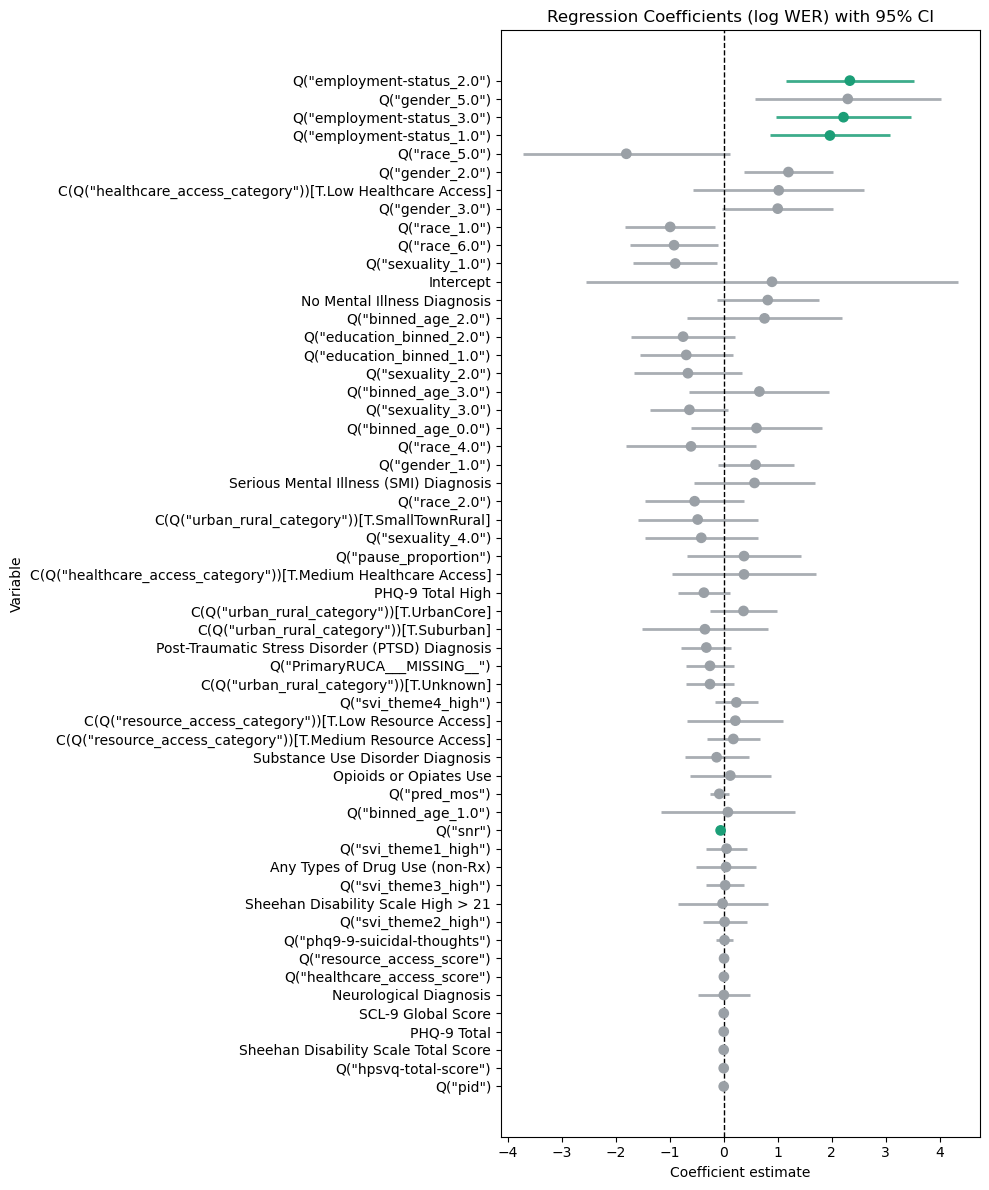

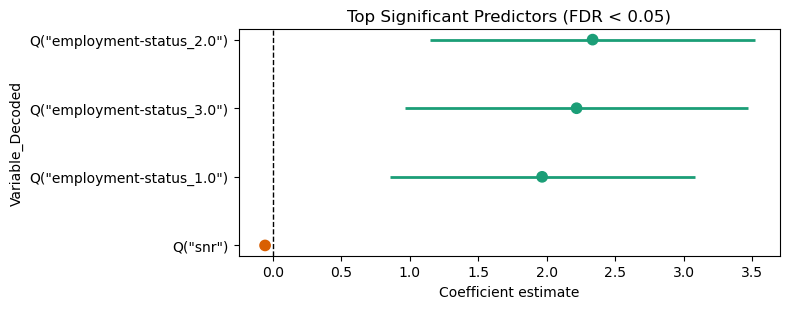

In [34]:
# Add Graph of Multi-Hypothesis corrected results
# Made this cell using Codex
# Top significant predictors only (FDR-significant), sorted by absolute effect size
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from avh_utils import decode_variable_name

# Add decoded variable names for better readability
# Use a safe wrapper to handle any decoding errors
def safe_decode(var_name):
    try:
        return decode_variable_name(var_name)
    except Exception as e:
        # If decoding fails, return the original variable name
        return var_name

# Load results
df = pd.read_csv("/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv")

# Clean/prepare
for col in ["fdr_significant", "bonferroni_significant"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})
df["ci_low"] = df["Coefficient"] - 1.96 * df["Std_Error"]
df["ci_high"] = df["Coefficient"] + 1.96 * df["Std_Error"]

# Optional: drop intercept for readability
plot_df = df[df["Variable"] != "const"].copy()
# Add variable decodes
plot_df['Variable_Decoded'] = plot_df['Variable'].apply(safe_decode)
# Build decoded labels (fallback to original if decode fails/empty)
plot_df["Variable_Decoded"] = (
    plot_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(plot_df["Variable"])
)
plot_df["Variable_Decoded"] = np.where(
    plot_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    plot_df["Variable"],
    plot_df["Variable_Decoded"]
)


# Sort by effect size magnitude
plot_df = plot_df.reindex(plot_df["Coefficient"].abs().sort_values(ascending=True).index)

# Plot: coefficient forest plot with 95% CI
plt.figure(figsize=(10, 12))
colors = np.where(plot_df["fdr_significant"], "#1b9e77", "#9aa0a6")

plt.hlines(
    y=plot_df["Variable_Decoded"],
    xmin=plot_df["ci_low"],
    xmax=plot_df["ci_high"],
    color=colors,
    alpha=0.85,
    linewidth=2
)
plt.scatter(
    plot_df["Coefficient"],
    plot_df["Variable_Decoded"],
    c=colors,
    s=45,
    zorder=3
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Regression Coefficients (log WER) with 95% CI")
plt.xlabel("Coefficient estimate")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


sig_df = df[(df["Variable"] != "const") & (df["fdr_significant"] == True)].copy()
# Build decoded labels (fallback to original if decode fails/empty)
sig_df["Variable_Decoded"] = (
    sig_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(sig_df["Variable"])
)
sig_df["Variable_Decoded"] = np.where(
    sig_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    sig_df["Variable"],
    sig_df["Variable_Decoded"]
)
if sig_df.empty:
    print("No FDR-significant predictors found.")
else:
    sig_df["ci_low"] = sig_df["Coefficient"] - 1.96 * sig_df["Std_Error"]
    sig_df["ci_high"] = sig_df["Coefficient"] + 1.96 * sig_df["Std_Error"]
    sig_df = sig_df.reindex(sig_df["Coefficient"].abs().sort_values(ascending=True).index)

    plt.figure(figsize=(8, max(3, 0.8 * len(sig_df))))
    colors = np.where(sig_df["Coefficient"] >= 0, "#1b9e77", "#d95f02")

    plt.hlines(
        y=sig_df["Variable_Decoded"],
        xmin=sig_df["ci_low"],
        xmax=sig_df["ci_high"],
        color=colors,
        linewidth=2
    )
    plt.scatter(sig_df["Coefficient"], sig_df["Variable_Decoded"], c=colors, s=55, zorder=3)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Top Significant Predictors (FDR < 0.05)")
    plt.xlabel("Coefficient estimate")
    plt.ylabel("Variable_Decoded")
    plt.tight_layout()
    plt.show()


In [35]:
# Model registry writer (v1)
# Appends/updates minimal model registry rows for current runs.

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import subprocess

REGISTRY_PATH = Path("/edata/obdw/sandwich_analysis_data/model_registry.csv")
DATASET_PATH = Path("/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv")

# Outcome-specific output artifacts
PY_OUTPUT_WER = Path("/edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv")
R_OUTPUT_WER = Path("/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv")
PARITY_SUMMARY_WER = Path("/edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv")

PY_OUTPUT_COH = Path("/edata/obdw/sandwich_analysis_data/regression_stratified_Y_COH.csv")
R_OUTPUT_COH = Path("/edata/obdw/sandwich_analysis_data/location_stratified_analysis_coh_coeftest.csv")
PARITY_SUMMARY_COH = Path("/edata/obdw/sandwich_analysis_data/python_vs_r_stratified_coh_comparison_summary.csv")

REQUIRED_COLUMNS = [
    "run_id", "model_id", "timestamp_utc", "script_stage", "notebook_or_script",
    "dataset_path", "outcome", "model_family", "cluster_var", "formula_text",
    "n_rows", "n_clusters", "predictor_count", "dropped_predictors", "correction_method",
    "r_output_path", "py_output_path", "parity_output_path",
    "parity_missing_variable_n", "parity_numeric_mismatch_n", "qa_status", "notes",
]

def _safe_git_value(cmd):
    try:
        return subprocess.check_output(cmd, text=True).strip()
    except Exception:
        return None

def _get_parity_counts(summary_path: Path):
    if summary_path is None or not summary_path.exists():
        return None, None
    try:
        s = pd.read_csv(summary_path)
        missing_n = int(s.loc[s["flag"] == "missing_variable", "n_terms"].sum())
        numeric_n = int(s.loc[s["flag"] == "numeric_mismatch", "n_terms"].sum())
        return missing_n, numeric_n
    except Exception:
        return None, None

def _get_model_dimensions(dataset_path: Path):
    # Prefer in-memory X_stratified if present; otherwise read from disk.
    if "X_stratified" in globals() and isinstance(X_stratified, pd.DataFrame):
        df = X_stratified
    elif dataset_path.exists():
        df = pd.read_csv(dataset_path, index_col=0)
    else:
        return None, None, None

    n_rows = int(df.shape[0])
    n_clusters = int(df["pid"].nunique()) if "pid" in df.columns else None

    exclude = {
        "WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH", "pid"
    }
    predictor_count = int(sum(1 for c in df.columns if c not in exclude))
    return n_rows, n_clusters, predictor_count

def write_model_registry_entry(
    run_id: str,
    model_id: str,
    outcome: str,
    py_output_path: Path,
    r_output_path: Path,
    parity_summary_path: Path = None,
    script_stage: str = "parity",
    notes: str = "",
):
    n_rows, n_clusters, predictor_count = _get_model_dimensions(DATASET_PATH)
    missing_n, numeric_n = _get_parity_counts(parity_summary_path)

    dropped = globals().get("columns_to_drop", [])
    if isinstance(dropped, (list, tuple, set)):
        dropped_predictors = ";".join([str(x) for x in dropped])
    else:
        dropped_predictors = None

    if missing_n is None and numeric_n is None:
        qa_status = "unknown"
    else:
        qa_status = "pass" if (missing_n == 0 and numeric_n == 0) else "fail"

    entry = {
        "run_id": run_id,
        "model_id": model_id,
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "script_stage": script_stage,
        "notebook_or_script": "primary_data_collection_script.ipynb",
        "dataset_path": str(DATASET_PATH),
        "outcome": outcome,
        "model_family": "ols_cluster",
        "cluster_var": "pid",
        "formula_text": None,
        "n_rows": n_rows,
        "n_clusters": n_clusters,
        "predictor_count": predictor_count,
        "dropped_predictors": dropped_predictors,
        "correction_method": "bonferroni,fdr_bh",
        "r_output_path": str(r_output_path),
        "py_output_path": str(py_output_path),
        "parity_output_path": str(parity_summary_path) if parity_summary_path else None,
        "parity_missing_variable_n": missing_n,
        "parity_numeric_mismatch_n": numeric_n,
        "qa_status": qa_status,
        "notes": notes,
        # Optional fields kept for traceability.
        "git_branch": _safe_git_value(["git", "rev-parse", "--abbrev-ref", "HEAD"]),
        "git_commit": _safe_git_value(["git", "rev-parse", "HEAD"]),
    }

    new_row = pd.DataFrame([entry])

    if REGISTRY_PATH.exists():
        registry = pd.read_csv(REGISTRY_PATH)
    else:
        registry = pd.DataFrame(columns=REQUIRED_COLUMNS + ["git_branch", "git_commit"])

    for c in REQUIRED_COLUMNS + ["git_branch", "git_commit"]:
        if c not in registry.columns:
            registry[c] = pd.NA

    # Upsert on (run_id, model_id) to avoid duplicate rows from reruns.
    match = (registry["run_id"].astype(str) == str(run_id)) & (registry["model_id"].astype(str) == str(model_id))
    registry = registry.loc[~match].copy()
    registry = pd.concat([registry, new_row], ignore_index=True)

    REGISTRY_PATH.parent.mkdir(parents=True, exist_ok=True)
    registry.to_csv(REGISTRY_PATH, index=False)

    print(f"Registry written: {REGISTRY_PATH}")
    print(f"Total rows: {len(registry)}")
    display(registry.tail(5))

# ---- Write v1 entries for current WER and COH runs ----
run_id = datetime.now(timezone.utc).strftime("%Y-%m-%d") + "_run01"

write_model_registry_entry(
    run_id=run_id,
    model_id="wer_stratified_v1",
    outcome="Y_WER",
    py_output_path=PY_OUTPUT_WER,
    r_output_path=R_OUTPUT_WER,
    parity_summary_path=PARITY_SUMMARY_WER,
    script_stage="parity",
    notes="WER registry entry with parity summary",
)

write_model_registry_entry(
    run_id=run_id,
    model_id="coh_stratified_v1",
    outcome="Y_COH",
    py_output_path=PY_OUTPUT_COH,
    r_output_path=R_OUTPUT_COH,
    parity_summary_path=PARITY_SUMMARY_COH,
    script_stage="model",
    notes="COH registry entry (parity summary optional)",
)


Registry written: /edata/obdw/sandwich_analysis_data/model_registry.csv
Total rows: 2


,run_id,model_id,timestamp_utc,script_stage,notebook_or_script,dataset_path,outcome,model_family,cluster_var,formula_text,...,correction_method,r_output_path,py_output_path,parity_output_path,parity_missing_variable_n,parity_numeric_mismatch_n,qa_status,notes,git_branch,git_commit
0,2026-04-21_run01,coh_stratified_v1,2026-04-21T23:02:18Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,49749bf3b03954e29203e172776be4a066c403c0
1,2026-04-21_run01,wer_stratified_v1,2026-04-21T23:07:25Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,None,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,49749bf3b03954e29203e172776be4a066c403c0


Registry written: /edata/obdw/sandwich_analysis_data/model_registry.csv
Total rows: 2


/tmp/ipykernel_270696/3642507082.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  registry = pd.concat([registry, new_row], ignore_index=True)


,run_id,model_id,timestamp_utc,script_stage,notebook_or_script,dataset_path,outcome,model_family,cluster_var,formula_text,...,correction_method,r_output_path,py_output_path,parity_output_path,parity_missing_variable_n,parity_numeric_mismatch_n,qa_status,notes,git_branch,git_commit
0,2026-04-21_run01,wer_stratified_v1,2026-04-21T23:07:25Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,49749bf3b03954e29203e172776be4a066c403c0
1,2026-04-21_run01,coh_stratified_v1,2026-04-21T23:07:25Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,None,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,49749bf3b03954e29203e172776be4a066c403c0
